# Normalised linear stability spectra

## Packages

In [1]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams.update({'figure.autolayout': True,
                 "text.usetex": True,
                 "font.family": "Computer Modern Roman"})


## Plotting font options ##
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

import numpy as np

from pathlib import PosixPath
user_home_path = PosixPath('~/')
user_home_path_full = user_home_path.expanduser()

import sys
sys.path.append("../")

import autolib
import dynplot
import Optimisation.opt as opt
import parameters
I_par, L, m, c = parameters.Parameters()


l_width = 2.5
colorY = "blue"
colorvY = "dodgerblue"  #cornflowerblue
colorphi = "red"  #"royalblue"
colorvphi = "tomato"  #coral
colorReal = (0.7, 0, 0)
colorImag = 'blue'
colorY2 = "blue"
colorvY2 = "red"  #cornflowerblue
colorphi2 = "black"  #"royalblue"
colorvphi2 = "lightgreen"  #coral

## Load the chosen grating

In [2]:
runID = "Fasympmonochrome_fixgaussian20_50GW_nG30"
I = I_par
final_speed = 20.
speed_range = np.array([0.,final_speed])
wavelength_range = [0.99999,1.0000004]

num_points = 200
normalise = False  # Normalise the Jacobian
use_perturbed = True

# Calculate the linear stability information for the chosen grating whose eigenvectors 
# you wish to plot alongside the dynamics
num_cores = 200
maxtime = 1440
output_opt_idx = 4

# Define the file paths for the optimisation results
common_path = user_home_path_full / "Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/Doppler Damping - Jadon Lin/Documentation/Data/relativistic-lightsail-dynamics/Optimisation/Jadon's results"
# custom_folder_path = f"Fasymp/final_speed{int(final_speed)}/maxtime{int(maxtime)}/{runID}"
custom_folder_path = f"Fasymp/mono/maxtime{int(maxtime)}/{runID}"
fname_preamble = common_path / custom_folder_path

pkl_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}'

_, _, grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=output_opt_idx)
grating.npa = autolib.AutoLib('torch', device='cpu', precision='double')  # twobox.npa isn't saved during optimisation, must set manually
print(grating.params)


wavelengths = np.linspace(*wavelength_range, num_points)

xs = (wavelengths-0.99999)*1e6
xlabel = r"$\lambda' - 0.99999 \mu$m [pm]"

# Save path
common_path = user_home_path_full / "Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/Doppler Damping - Jadon Lin/Documentation/Data/relativistic-lightsail-dynamics/Dynamics"
# custom_folder_path = f"Fasymp/final_speed{int(final_speed)}/maxtime{int(maxtime)}/{runID}/opt{output_opt_idx}"
custom_folder_path = f"Fasymp/mono/maxtime{int(maxtime)}/{runID}/opt{output_opt_idx}"
fname_preamble = common_path / custom_folder_path
fname_preamble.mkdir(parents=True, exist_ok=True)

Total function evaluations: 7171191
Average function evaluations per core: 35855
[tensor(1.5890, dtype=torch.float64), tensor(0.6815, dtype=torch.float64), tensor(1.1635, dtype=torch.float64), tensor(1.2270, dtype=torch.float64), tensor(0.4843, dtype=torch.float64), tensor(12.2500, dtype=torch.float64), tensor(8.4398, dtype=torch.float64), tensor(1.8405, dtype=torch.float64), tensor(7.7248, dtype=torch.float64)]


### Calculate Jacobian terms at fixed wavelength

In [3]:
import fom

# Ordering:
# row1 = (kyy, kyphi, muyy, muyphi)
# row2 = (kphiy, kphiphi, muphiy, muphiphi)

jac = fom.force_coeff(grating, I, m=1/1000, c1=299792458, grad_method='grad', out="mat", normalise=False)
print(jac)

tensor([[-8.4134e+01,  4.2411e+03, -3.2699e-04, -1.7191e+00],
        [ 9.8901e+02, -6.4979e+04, -2.1675e-04, -1.9518e+00]],
       dtype=torch.float64, grad_fn=<StackBackward0>)


## Calculate lsa quantities

In [4]:
lsa = dynplot.generate_lsa_spectrum(grating, speed_range, I, num_points, normalise=normalise, use_perturbed=use_perturbed, wavelength_range=wavelength_range)
restoring_coeffs, damping_coeffs, real_eigvals, imag_eigvals, eigvec_moduli, preal_eigvals, pimag_eigvals = lsa

# Jacobians terms directly from Qpr derivatives
kyy, kyphi, kphiy, kphiphi = restoring_coeffs.T
muyy, muyphi, muphiy, muphiphi = damping_coeffs.T

## Eigenvalues and eigenvectors

### Eigenvalues only

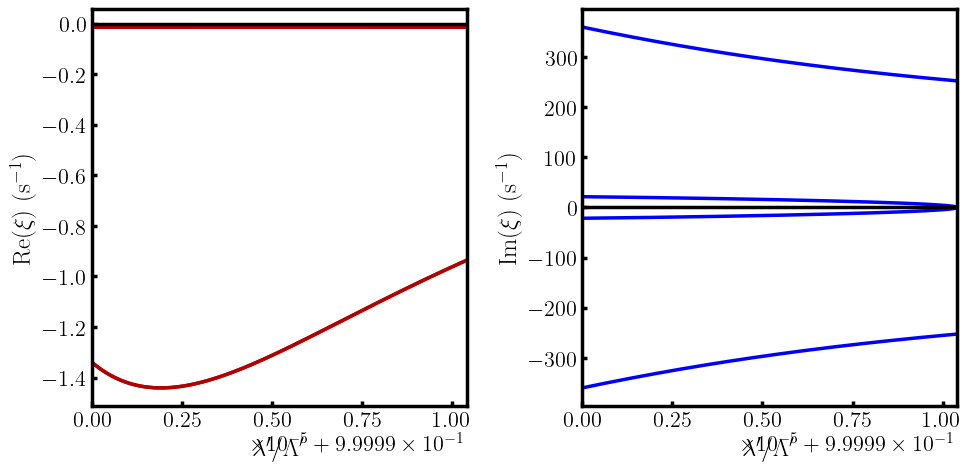

In [18]:
# Plot eigenvectors separately
log_axis = False
eigval_fig, axs = plt.subplots(1,2, figsize=(10,5))

axs_flat = axs.flatten()
axs_flat[0].plot(xs, real_eigvals, color=colorReal, linewidth=l_width)
axs_flat[1].plot(xs, imag_eigvals, color=colorImag, linewidth=l_width)
axs_flat[0].set_yscale('linear')
axs_flat[1].set_yscale('linear')
axs_flat[0].set(xlim=(xs[0],xs[-1]))
axs_flat[1].set(xlim=(xs[0],xs[-1]))
dynplot.show_standard_axes(axs_flat[0], None, xlabel=xlabel, ylabel=r"$\Re(\xi)$ (s$^{-1}$)" if not normalise else r"$\Re(\bar{\xi})$", show_zero_line=True)
dynplot.show_standard_axes(axs_flat[1], None, xlabel=xlabel, ylabel=r"$\Im(\xi)$ (s$^{-1}$)" if not normalise else r"$\Im(\bar{\xi})$", show_zero_line=True)
    
ftype = ".pdf"
save_fname = str(fname_preamble) + f"/{runID}_eigval_normalise{normalise}" + ftype
eigval_fig.savefig(save_fname, bbox_inches="tight")

### First-order perturbation eigenvalues from Jacobian terms

[-0.00055701 -0.00055513 -0.00055325 -0.00055139 -0.00054953 -0.00054767
 -0.00054583 -0.00054399 -0.00054217 -0.00054035]
[-2.70831763 -2.72065782 -2.73252349 -2.74392339 -2.75486616 -2.76536036
 -2.77541441 -2.78503664 -2.79423526 -2.8030184 ]
[2.65002731 2.66245126 2.67439973 2.68588146 2.69690508 2.70747912
 2.71761202 2.72731208 2.73658751 2.74544642]


<Axes: ylabel='$\\Im(\\xi)$ (s$^{-1}$)'>

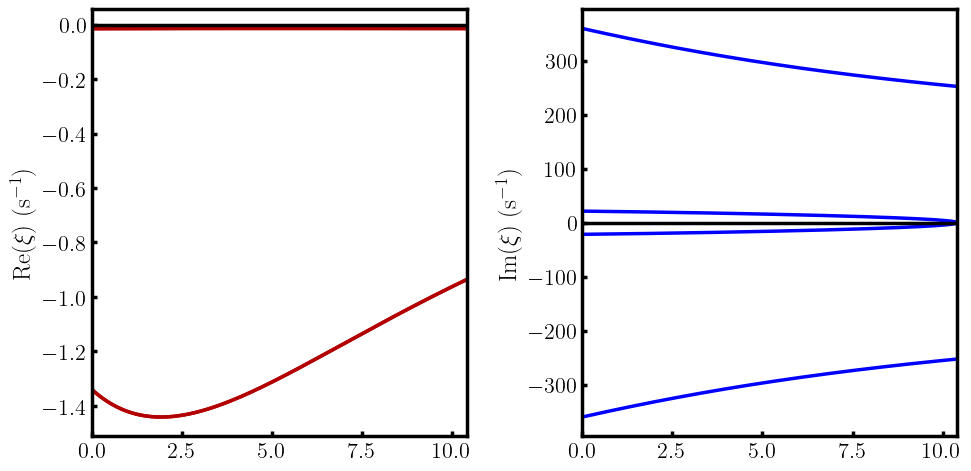

In [83]:
base_root = np.sqrt(4*kyphi*kphiy + (kyy - kphiphi)**2)

# Unperturbed eigenvalues (positive only)
eigval_unp1 = 1/np.sqrt(2)*np.sqrt(kyy + kphiphi - base_root, dtype=np.complex128)
eigval_unp3 = 1/np.sqrt(2)*np.sqrt(kyy + kphiphi + base_root, dtype=np.complex128)

mix = kyphi*muphiy + kphiy*muyphi
diag_diff = (kyy - kphiphi)*(muyy - muphiphi)

real_eigval1 = 1/4 * (muyy + muphiphi - (2*mix + diag_diff)/base_root)
real_eigval3 = 1/4 * (muyy + muphiphi + (2*mix + diag_diff)/base_root)

eigval1 = -eigval_unp1 + 1/4 * (muyy + muphiphi - (2*mix + diag_diff)/base_root)
eigval2 = eigval_unp1 + 1/4 * (muyy + muphiphi - (2*mix + diag_diff)/base_root)
eigval3 = -eigval_unp3 + 1/4 * (muyy + muphiphi + (2*mix + diag_diff)/base_root)
eigval4 = eigval_unp3 + 1/4 * (muyy + muphiphi + (2*mix + diag_diff)/base_root)

cross = (2*mix + diag_diff)/base_root
print(muyy[:10])
print(muphiphi[:10])
print(cross[:10])

real_pert_eigvals = np.real(np.array([eigval1, eigval2, eigval3, eigval4]).T)
imag_pert_eigvals = np.imag(np.array([eigval1, eigval2, eigval3, eigval4]).T)

pert_eig_fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].plot(xs, real_pert_eigvals, color=colorReal, linewidth=l_width)
ax[1].plot(xs, imag_pert_eigvals, color=colorImag, linewidth=l_width)

# Check the analytic real part:
# ax[0].plot(xs, real_eigval1, color="green", linewidth=l_width, linestyle='--')
# ax[0].plot(xs, real_eigval3, color="green", linewidth=l_width, linestyle='--')

ax[0].set_yscale('linear')
ax[1].set_yscale('linear')
ax[0].set(xlim=(xs[0],xs[-1]))
ax[1].set(xlim=(xs[0],xs[-1]))
dynplot.show_standard_axes(ax[0], None, xlabel=None, ylabel=r"$\Re(\xi)$ (s$^{-1}$)", show_zero_line=True)
dynplot.show_standard_axes(ax[1], None, xlabel=None, ylabel=r"$\Im(\xi)$ (s$^{-1}$)", show_zero_line=True)

# ftype = ".pdf"
# save_fname = str(fname_preamble) + f"/{runID}_eigval_perturb" + ftype
# eigval_fig.savefig(save_fname, bbox_inches="tight")

### Perturbed eigenvalue dominant expressions

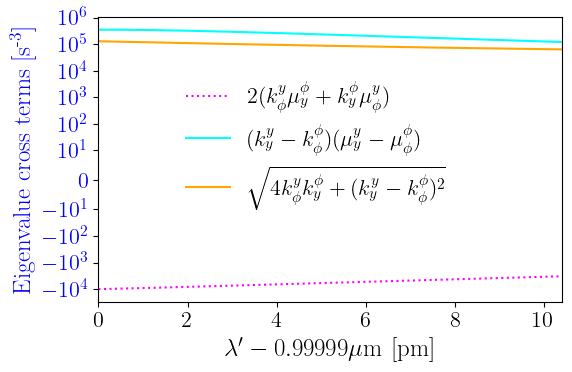

In [45]:
################
# Restoring terms
pert_terms_fig, ax = plt.subplots(1,figsize=(6,4))

km_mix = 2*(kyphi*muphiy + kphiy*muyphi)
diag_diff = (kyy - kphiphi)*(muyy - muphiphi)
base_root = np.sqrt(4*kyphi*kphiy + (kyy - kphiphi)**2)

ax.plot(xs, km_mix, label=r"$2(k^y_\phi \mu^\phi_y + k_y^\phi \mu_\phi^y)$", color="magenta", linestyle="dotted")
ax.plot(xs, diag_diff, label=r"$(k^y_y - k^\phi_\phi)(\mu^y_y - \mu^\phi_\phi)$", color="cyan")
ax.plot(xs, base_root, label=r"$\sqrt{4k^y_\phi k^\phi_y + (k^y_y - k^\phi_\phi)^2}$", color="orange")

ax.set_xlabel(xlabel)
ay_coord_label = r"Eigenvalue cross terms [s\textsuperscript{-3}]"
ax.set_ylabel(ay_coord_label,color=colorY)
ax.tick_params(axis='y',labelcolor=colorY)

# ax.set_ylim(t)
ax.set_yscale('symlog', linthresh=10)
ax.set_xlim(xs[0],xs[-1])

pert_terms_fig.legend(loc='center left', bbox_to_anchor=(0.3,0.6), frameon=False)

pert_terms_fig.tight_layout()
ftype = ".pdf"
save_fname = str(fname_preamble) + f"/{runID}_dominant_perturbed_terms" + ftype
# pert_terms_fig.savefig(save_fname, bbox_inches="tight")

### Taking first order in the base root

Assuming $(k^y_y-k^\phi_\phi)^2 \gg |4k^y_\phi k^\phi_y|$, we can take a first-order Taylor expansion of the denominator to simplify the eigenvalues to the following:
$$ 
\begin{align}
    \Re(\xi_\text{weak}) 
    &\approx 
    \frac{1}{2} \left[\mu^y_y - \frac{k^y_\phi \mu^\phi_y + k_y^\phi \mu_\phi^y}{k^\phi_\phi - k_y^y} \right]
    \\
    \Re(\xi_\text{dominant}) 
    &\approx 
    \frac{1}{2} \left[\mu^\phi_\phi + \frac{k^y_\phi \mu^\phi_y + k_y^\phi \mu_\phi^y}{k^\phi_\phi - k_y^y} \right]
\end{align}
$$

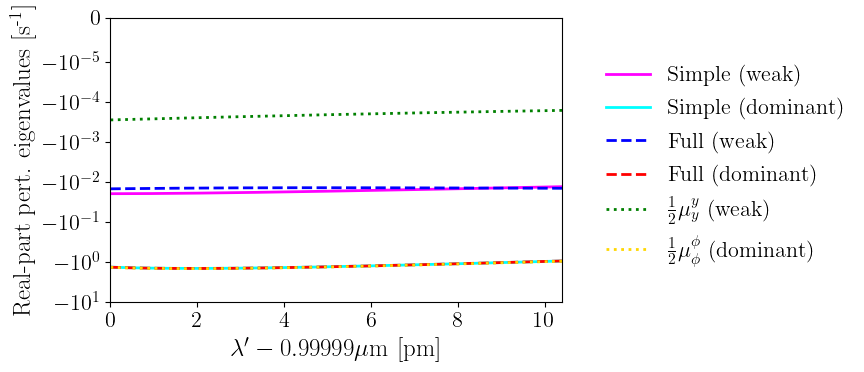

In [79]:
################
# Restoring terms
simple_fig, ax = plt.subplots(1,figsize=(6,4))

km_mix = 2*(kyphi*muphiy + kphiy*muyphi)
rest_diff = kphiphi - kyy
cross = km_mix/(2*rest_diff)

simple_eig1 = 1/2 * (muyy - cross)
simple_eig3 = 1/2 * (muphiphi + cross)

ax.plot(xs, simple_eig1, label=r"Simple (weak)", linewidth=2., color="magenta")
ax.plot(xs, simple_eig3, label=r"Simple (dominant)", linewidth=2., color="cyan")
ax.plot(xs, np.real(eigval3), label="Full (weak)", color="blue", linewidth=2., linestyle="dashed")
ax.plot(xs, np.real(eigval1), label="Full (dominant)", color="red", linewidth=2., linestyle="dashed")

ax.plot(xs, 1/2*muyy, label=r"$\frac{1}{2}\mu^y_y$ (weak)", color="green", linewidth=2., linestyle="dotted")
ax.plot(xs, 1/2*muphiphi, label=r"$\frac{1}{2}\mu^\phi_\phi$ (dominant)", color="gold", linewidth=2., linestyle="dotted")

ax.set_xlabel(xlabel)
ay_coord_label = r"Real-part pert. eigenvalues [s\textsuperscript{-1}]"
ax.set_ylabel(ay_coord_label)

ax.set_yscale('symlog', linthresh=1e-5)
ax.set_xlim(xs[0],xs[-1])
ax.set_ylim(-10,0)

simple_fig.legend(loc='center left', bbox_to_anchor=(1.,0.55), frameon=False)

simple_fig.tight_layout()
ftype = ".pdf"
save_fname = str(fname_preamble) + f"/{runID}_simplified_eigenvalues" + ftype
simple_fig.savefig(save_fname, bbox_inches="tight")

### Both

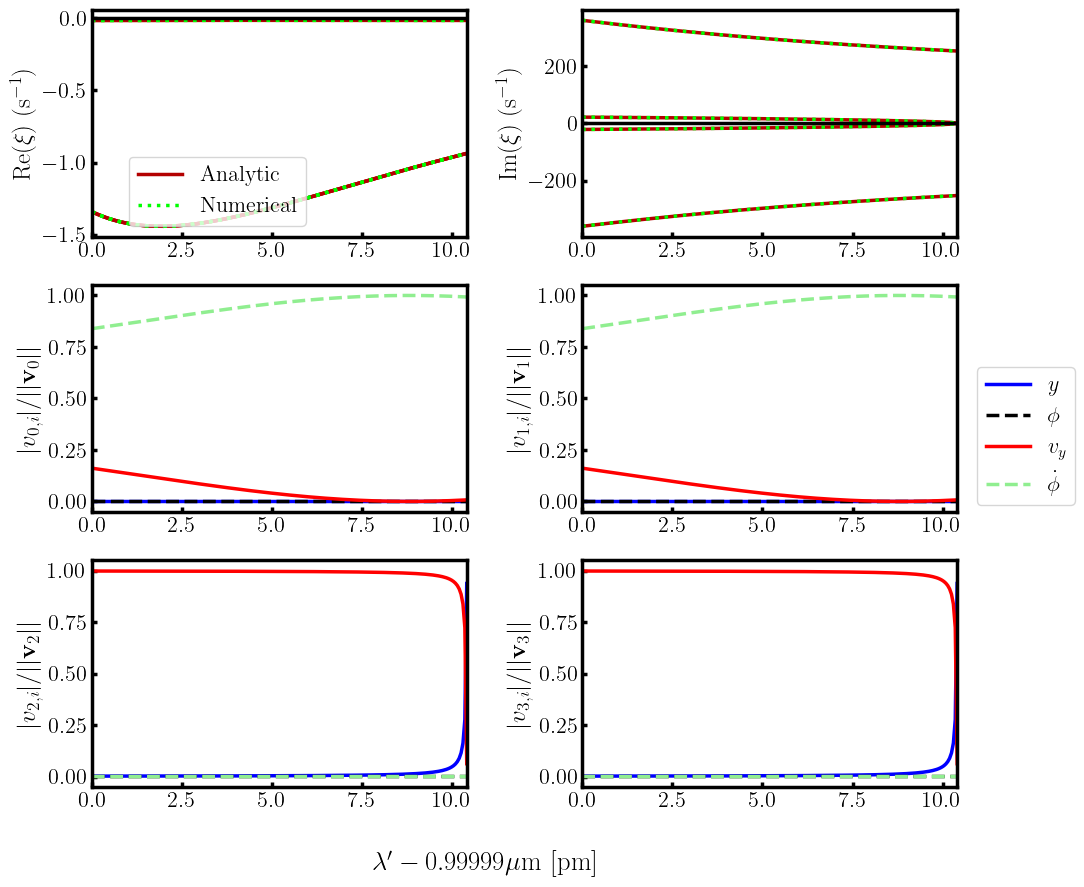

In [16]:
# Plot eigenvectors separately
log_axis = False
eigvec_fig, axs = plt.subplots(3,2, figsize=(10,9))

axs_flat = axs.flatten()
if use_perturbed:
    axs_flat[0].plot(xs, preal_eigvals, color=colorReal, linewidth=l_width)
    axs_flat[0].plot(xs, preal_eigvals[:,0], color=colorReal, linewidth=l_width, label=r"Analytic")  # for legend label
    axs_flat[1].plot(xs, pimag_eigvals, color=colorReal, linewidth=l_width)
    axs_flat[0].plot(xs, real_eigvals, color="lime", linewidth=l_width, linestyle=':')
    axs_flat[0].plot(xs, real_eigvals[:,0], color="lime", linewidth=l_width, linestyle=':', label=r"Numerical")
    axs_flat[1].plot(xs, imag_eigvals, color="lime", linewidth=l_width, linestyle=':')
    axs_flat[0].legend(loc='center right', bbox_to_anchor=(0.6,0.2))
else:
    axs_flat[0].plot(xs, real_eigvals, color=colorReal, linewidth=l_width)
    axs_flat[1].plot(xs, imag_eigvals, color=colorImag, linewidth=l_width)
axs_flat[0].set_yscale('linear')
axs_flat[1].set_yscale('linear')
axs_flat[0].set(xlim=(xs[0],xs[-1]))
axs_flat[1].set(xlim=(xs[0],xs[-1]))
dynplot.show_standard_axes(axs_flat[0], None, xlabel=None, ylabel=r"$\Re(\xi)$ (s$^{-1}$)" if not normalise else r"$\Re(\bar{\xi})$", show_zero_line=True)
dynplot.show_standard_axes(axs_flat[1], None, xlabel=None, ylabel=r"$\Im(\xi)$ (s$^{-1}$)" if not normalise else r"$\Im(\bar{\xi})$", show_zero_line=True)

axs_flat = axs_flat[2:]
# axs_flat[1], axs_flat[2] = axs_flat[2], axs_flat[1]  # switch so that degenerate eigvec magnitudes are shown in columns
for eigvec_idx, ax in enumerate(axs_flat):
    ax.plot(xs, eigvec_moduli[:,0,eigvec_idx], label=r"$y$" if not normalise else r"$\bar{y}$", color=colorY2, linewidth=l_width)
    ax.plot(xs, eigvec_moduli[:,1,eigvec_idx], label=r"$\phi$", color=colorphi2, linewidth=l_width, linestyle="--")
    ax.plot(xs, eigvec_moduli[:,2,eigvec_idx], label=r"$v_y$" if not normalise else r"$\bar{v}_y$", color=colorvY2, linewidth=l_width)
    ax.plot(xs, eigvec_moduli[:,3,eigvec_idx], label=r"$\dot{\phi}$" if not normalise else r"$\bar{\dot{\phi}}$", color=colorvphi2, linewidth=l_width, linestyle="--")

    if log_axis:
        ax.set(xlim=(xs[0],xs[-1]), ylim=(1e-9,1e1))
        ax.set_yscale('log')
    else:
        ax.set(xlim=(xs[0],xs[-1]), ylim=(-0.05,1.05))
    nd_ylabel = rf"$|v_{{{eigvec_idx},i}}|/||\mathbf{{v}}_{{{eigvec_idx}}}||$" if not normalise else rf"$|\bar{{v}}_{{{eigvec_idx},i}}|/||\bar{{\mathbf{{v}}}}_{{{eigvec_idx}}}||$"
    ax = dynplot.show_standard_axes(ax, None, xlabel=None, ylabel=nd_ylabel, show_zero_line=False)
    

eigvec_fig.supxlabel(xlabel)
handles, labels = ax.get_legend_handles_labels()
leg = eigvec_fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.1,0.5))

ftype = ".pdf"
save_fname = str(fname_preamble) + f"/{runID}_eigen_normalise{normalise}" + ftype
eigvec_fig.savefig(save_fname, bbox_inches="tight")

## Quality factor

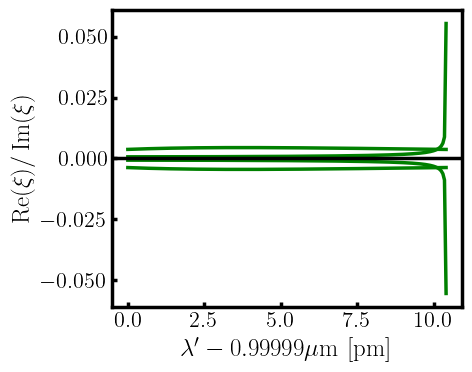

In [17]:
q_fig, q_ax = plt.subplots(1, figsize=(5,4))
q_ax.plot(xs, real_eigvals/imag_eigvals, color="green", linewidth=l_width)
ylabel = r"$\Re(\xi)/\Im(\xi)$" if not normalise else r"$\Re(\bar{\xi})/\Im(\bar{\xi})$"
dynplot.show_standard_axes(q_ax, None, xlabel=xlabel, ylabel=ylabel, show_zero_line=True)

save_fname = str(fname_preamble) + f"/{runID}_quality_factor_normalise{normalise}" + ftype
q_fig.savefig(save_fname, bbox_inches="tight")

## Jacobian terms spectra

### All terms

Grouped by acceleration or angular acceleration

Can choose to calculate the Jacobian terms using Qpr derivatives or directly from the diffraction derivatives.

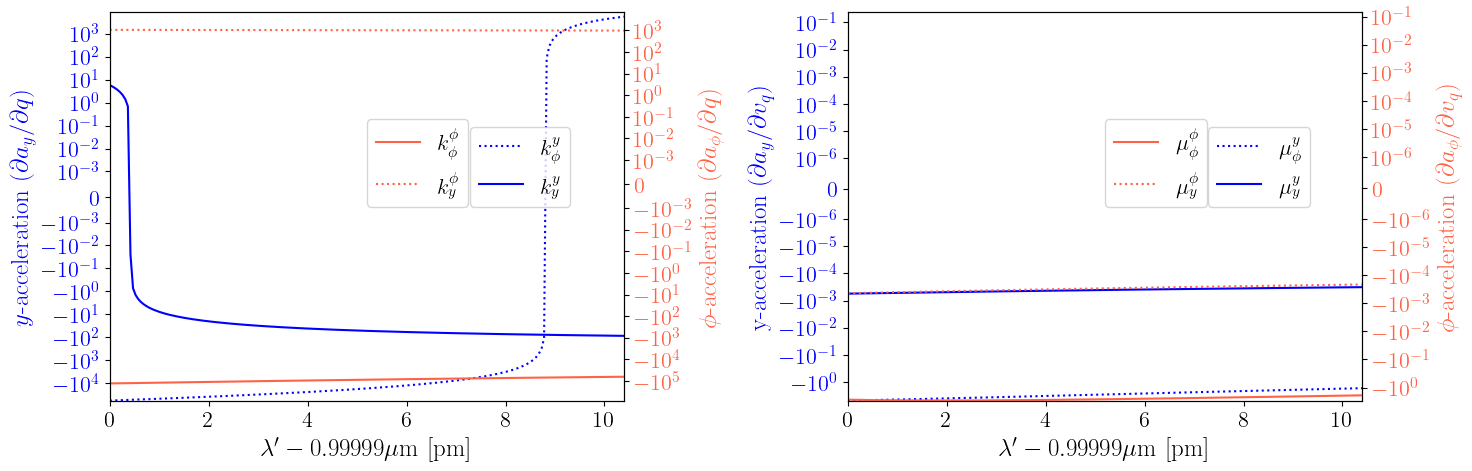

In [46]:
################
# Restoring terms
stiff_fig,(ax, ax2) = plt.subplots(1,2,figsize=(15,5))


ax.plot(xs, kyphi,  label=r"$k^y_\phi$",color=colorY,linestyle="dotted")
ax.plot(xs, kyy,    label=r"$k^y_y$",color=colorY)

ax.set_xlabel(xlabel)
ay_coord_label = r"Norm. $y$-acceleration ($\partial a_y/\partial q$)" if normalise else r"$y$-acceleration ($\partial a_y/\partial q$)"
ax.set_ylabel(ay_coord_label,color=colorY)
ax.tick_params(axis='y',labelcolor=colorY)

# ax.hlines(0,0,5,"k","dashed",alpha=0.2)
t = ax.get_ylim()
# ax.axhspan(0,t[1],color='black',alpha=0.2)

ax1 = ax.twinx()
ax1.plot(xs, kphiy,  label=r"$k^\phi_y$",color=colorvphi,linestyle="dotted")
ax1.plot(xs,kphiphi,label=r"$k^\phi_\phi$",color=colorvphi)

aphi_coord_label = r"Norm. $\phi$-acceleration ($\partial a_\phi/\partial q$)" if normalise else r"$\phi$-acceleration ($\partial a_\phi/\partial q$)"
ax1.set_ylabel(aphi_coord_label,color=colorvphi)
ax1.tick_params(axis='y',labelcolor=colorvphi)


# ax.set_ylim(t)
ax.set_yscale('symlog', linthresh=1e-3)
ax1.set_yscale('symlog', linthresh=1e-3)
ax.set_xlim(xs[0],xs[-1])

# ax.set_xticks([0,1,1.45,2,3,4,5])

handles, labels = ax.get_legend_handles_labels()
handles1, labels1 = ax1.get_legend_handles_labels()
order = [0,1]
order1=[1,0]
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],loc=(0.5+0.2,0.5))
ax1.legend([handles1[idx] for idx in order1],[labels1[idx] for idx in order1],loc=(0.5,0.5))

########################
ax2.plot(xs,muyphi, label=r"$\mu^y_\phi$", color=colorY,linestyle="dotted")
ax2.plot(xs,muyy, label=r"$\mu^y_y$",color=colorY)
ax2
ax2.set_xlabel(xlabel)
ay_vel_label = r"Norm. y-acceleration ($\partial a_y/\partial v_q$)" if normalise else r"y-acceleration ($\partial a_y/\partial v_q$)"
ax2.set_ylabel(ay_vel_label, color=colorY)
ax2.tick_params(axis='y', labelcolor=colorY)

t=ax2.get_ylim()
ax2b=ax2.twinx()

ax2b.plot(xs,muphiy, label=r"$\mu^\phi_y$",color=colorvphi,linestyle="dotted")
ax2b.plot(xs,muphiphi, label=r"$\mu^\phi_\phi$", color=colorvphi)

aphi_vel_label = r"Norm. $\phi$-acceleration ($\partial a_\phi/\partial v_q$)" if normalise else r"$\phi$-acceleration ($\partial a_\phi/\partial v_q$)"
ax2b.set_ylabel(aphi_vel_label,color=colorvphi)
ax2b.tick_params(axis='y',labelcolor=colorvphi)

ax2.set_ylim(t)
ax2.set_xlim(xs[0],xs[-1])
ax2.set_yscale('symlog', linthresh=1e-6)
ax2b.set_yscale('symlog', linthresh=1e-6)
 
handles, labels = ax2.get_legend_handles_labels()
handles1, labels1 = ax2b.get_legend_handles_labels()
order = [0,1]
order1=[1,0]
ax2.legend([handles[idx] for idx in order],[labels[idx] for idx in order],loc=(0.5+0.2,0.5))
ax2b.legend([handles1[idx] for idx in order1],[labels1[idx] for idx in order1],loc=(0.5,0.5))

stiff_fig.tight_layout()
ftype = ".pdf"
save_fname = str(fname_preamble) + f"/{runID}_jacobian_coefficients_normalise{normalise}" + ftype
stiff_fig.savefig(save_fname, bbox_inches="tight")


# Calculate the average damping coefficient
muyy_avg = np.mean(muyy)
mupp_avg = np.mean(muphiphi)
txt_fname = str(fname_preamble) + f"/average_damping.txt"
with open(txt_fname, 'w') as f:
    f.write(f"Average muyy: {muyy_avg:.2E}\n")
    f.write(f"Average mupp: {mupp_avg:.2E}\n")

### Only restoring force/torque

In [ ]:
stiff_fig, ax = plt.subplots(1,figsize=(6,4))

kyy, kyphi, kphiy, kphiphi = restoring_coeffs.T
muyy, muyphi, muphiy, muphiphi = damping_coeffs.T

ax.plot(betas, kyy,    label=r"$\bar{k}^y_y$",color=colorY)
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"Norm. $y$-acceleration ($\partial a_y/\partial q$)",color=colorY)
ax.tick_params(axis='y',labelcolor=colorY)

t = ax.get_ylim()
ax1 = ax.twinx()
ax1.plot(betas,kphiphi,label=r"$\bar{k}^\phi_\phi$",color=colorvphi)
ax1.set_ylabel(r"Norm. $\phi$-acceleration ($\partial a_\phi/\partial q$)",color=colorvphi)
ax1.tick_params(axis='y',labelcolor=colorvphi)

vels = [[b,0] for b in betas]
Dopplers = np.array(parameters.D1_ND(vels))
s1 = 1./Dopplers/grating.grating_pitch
c1 = np.sqrt(1 - s1**2)
w = grating.gaussian_width/L
w0_1 = 1 - np.exp(-1/(2*w*2))
w18_0 = (w/2)**2 * w0_1
ax1.plot(betas, -kyy/c1*w18_0/w0_1, 
         label=r"$-\frac{\bar{k}^y_y}{\cos\delta_1'}\frac{w^{\rightarrow 1/8}_{0\leftarrow}}{w^{\rightarrow 0}_{1\leftarrow}}$", 
         color="black")


ax.set_ylim(t)
ax.set_xlim(betas[0],betas[-1])

stiff_fig.legend(loc='center left', bbox_to_anchor=(1.0,0.5))

stiff_fig.tight_layout()
ftype = ".pdf"
save_fname = fname_preamble + f"/Dynamics/{runID}_restoring_coefficients" + ftype
# stiff_fig.savefig(save_fname, bbox_inches="tight")

grating.show_spectrum(0., "PDr", wavelength_range=[1,1.225])

## Other calculations

In [ ]:
# Cannot normalise Jacobian terms when calculating Routh-Hurwitz coefficients or eigen
restoring_coeffs, damping_coeffs, real_eigvals, imag_eigvals, eigvec_moduli = dynplot.generate_lsa_spectrum(grating, speed_range, I, num_points, normalise=False)
kyy, kyphi, kphiy, kphiphi = restoring_coeffs.T
muyy, muyphi, muphiy, muphiphi = damping_coeffs.T

betas = np.linspace(0,final_speed/100, num_points)

### Routh-Hurwitz stability

In [ ]:
muyy = muyy
kyphi = kyphi

a1 = -muyy - muphiphi
a2 = muyy*muphiphi - muyphi*muphiy - (kyy + kphiphi)
a3 = kyy*muphiphi + kphiphi*muyy - (kyphi*muphiy + kphiy*muyphi)
a4 = kyy*kphiphi - kyphi*kphiy

condition1 = a1
condition2 = a1*a2 - a3
condition3 = a3*condition2 - a1**2*a4
condition4 = a4

RH_fig, RH_ax = plt.subplots(1,figsize=(6,5))
RH_ax = dynplot.plot_array_on_same_axes(RH_ax, betas, condition1, linewidth=2.5, color="red", linestyle="-", label=r"Negative damping coeff")
RH_ax = dynplot.plot_array_on_same_axes(RH_ax, betas, condition2, linewidth=2.5, color="magenta", linestyle="--", label=r"Mixed 1")
RH_ax = dynplot.plot_array_on_same_axes(RH_ax, betas, condition3, linewidth=2.5, color="cyan", linestyle="--", label=r"Mixed 2")
RH_ax = dynplot.plot_array_on_same_axes(RH_ax, betas, condition4, linewidth=2.5, color="blue", linestyle="-", label=r"Restoring $\textgreater$ Coupling")
RH_ax = dynplot.show_standard_axes(RH_ax, betas, xlabel=r"$\beta$", ylabel=r"Routh-Hurwitz coefficients (arb. units)", show_zero_line=True, ax_width=2.5)
RH_fig.legend(loc='upper right')
RH_ax.set_yscale('log')

RH_fig.tight_layout()
ftype = ".pdf"
save_fname = fname_preamble + f"/Dynamics/{runID}_Routh_Hurwitz" + ftype
RH_fig.savefig(save_fname, bbox_inches="tight")

### Eigenvalues from scaled Jacobian terms

In [ ]:
scaled_eigval_fig, scaled_eigval_ax = plt.subplots(1,2,figsize=(10,4.5))
real_eigvals = []
imag_eigvals = []
for i in range(num_points):
    Jac = grating.npa.array([[0, 0, 1, 0],[0, 0, 0, 1], 
                             [kyy[i], kyphi[i], muyy[i], muyphi[i]], 
                             [kphiy[i], kphiphi[i], muphiy[i], muphiphi[i]]])
    eigvals = grating.npa.eigvals(Jac)
    real_eigvals.append(grating.npa.real(eigvals))
    imag_eigvals.append(grating.npa.imag(eigvals))
scaled_eigval_ax[0].plot(betas, grating.to_numpy(real_eigvals), color=colorReal, linewidth=l_width)
scaled_eigval_ax[1].plot(betas, grating.to_numpy(imag_eigvals), color=colorImag, linewidth=l_width)
scaled_eigval_ax[0].set_yscale('linear')
scaled_eigval_ax[1].set_yscale('linear')
scaled_eigval_ax[0].set(xlim=(betas[0],betas[-1]))
scaled_eigval_ax[1].set(xlim=(betas[0],betas[-1]))
dynplot.show_standard_axes(scaled_eigval_ax[0], None, xlabel=None, ylabel=r"$\Re(\xi)$ (s$^{-1}$)", show_zero_line=True)
dynplot.show_standard_axes(scaled_eigval_ax[1], None, xlabel=None, ylabel=r"$\Im(\xi)$ (s$^{-1}$)", show_zero_line=True)
scaled_eigval_fig.supxlabel(r"$\beta$")
# scaled_eigval_ax[0].set_yscale('symlog', linthresh=1e-5)
# scaled_eigval_ax[0].set_ylim(-3e-4,0.)

scaled_eigval_fig.tight_layout()
ftype = ".pdf"
save_fname = fname_preamble + f"/Dynamics/{runID}_scaled_Jacobian_eigenvalues" + ftype
scaled_eigval_fig.savefig(save_fname, bbox_inches="tight")

### Grating-optimum eigenvalue width dependence

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import dynplot
import fom
from parameters import Parameters
I0, L, m, c = Parameters()

num_points = 10
ws = np.linspace(0.001, 0.01, num_points)

# Real-part eigenvalues beam-width dependence
test = num_points
dim_eigmin_ws = np.zeros(num_points)
dim_eigmax_ws = np.zeros(num_points)
for i in range(test):
    grating.gaussian_width = ws[i]*L
    dim_eigmin_ws[i] = fom.multifom_uniform(grating, monofom=fom.monofom_asymp, final_speed=20., goal=0.1, return_grad=False)
    dim_eigmax_ws[i] = fom.multifom_uniform(grating, monofom=fom.monofom_max_eigval, final_speed=20., goal=0.1, return_grad=False)

In [ ]:
eigmin_ws = dim_eigmin_ws/np.max(np.abs(dim_eigmin_ws))  # Normalise to the maximum value
eigmax_ws = dim_eigmax_ws/np.max(np.abs(dim_eigmax_ws))  # Normalise to the maximum value

eigw_fig, eigw_ax = plt.subplots(1, figsize=(9,5))
eigw_ax.plot(ws, eigmin_ws, color="red", linewidth=2.5, label=r"$\text{minimum}[\Re(-\xi)]$")
eigw_ax.plot(ws, eigmax_ws, color="blue", linewidth=2.5, label=r"$\text{maximum}[\Re(-\xi)]$")
dynplot.show_standard_axes(eigw_ax, None, xlabel=r"$w/L$", ylabel=r"Average $\Re(-\xi)$ (norm.)", show_zero_line=True)
# eigw_ax.set(xlim=(ws[0], ws[-1]), ylim=(0., 1.05))
eigw_ax.set(xlim=(ws[0], ws[-1]))
eigw_ax.legend(loc='center left', frameon=False, bbox_to_anchor=(1., 0.55))

ftype = ".pdf"
save_fname = str(fname_preamble) + f"/{runID}_width_dependence{ws[-1]}" + ftype
eigw_fig.savefig(save_fname, bbox_inches="tight")

In [ ]:
normalise = False
start_idx = 0

if normalise:
    emin = dim_eigmin_ws / np.max(np.abs(dim_eigmin_ws))
    emax = dim_eigmax_ws / np.max(np.abs(dim_eigmax_ws))
    ylabel = r"Average $\Re(-\xi)$ (norm.)"
else:
    emin = dim_eigmin_ws
    emax = dim_eigmax_ws
    ylabel = r"Average $\Re(-\xi)$ (s$^{-1}$)"

eigw_fig, eigw_ax = plt.subplots(1, figsize=(9,5))
eigw_ax.plot(ws[start_idx:], emin[start_idx:], color="red", linewidth=2.5, label=r"$\text{minimum}[\Re(-\xi)]$")
eigw_ax.plot(ws[start_idx:], emax[start_idx:], color="blue", linewidth=2.5, label=r"$\text{maximum}[\Re(-\xi)]$")
dynplot.show_standard_axes(eigw_ax, None, xlabel=r"$w/L$", ylabel=ylabel, show_zero_line=True)
eigw_ax.set(xlim=(ws[start_idx], ws[-1]), ylim=(1e-6, 2.5e-4))
eigw_ax.set_yscale('log')
eigw_ax.legend(loc='center left', frameon=False, bbox_to_anchor=(1., 0.55))

max_arg = np.argmax(emin)
print(max_arg)
print(ws[max_arg])

ftype = ".pdf"
save_fname = str(fname_preamble) + f"/{runID}_width_dependence{ws[-1]}_normalise{normalise}" + ftype
eigw_fig.savefig(save_fname, bbox_inches="tight")

In [ ]:
# wkyy = fixed_power_ws[0]
# wkyp = fixed_power_ws[1]
# wkpp = fixed_power_ws[2] 
# wkpy = fixed_power_ws[3]
# wmpp = fixed_power_ws[4]
# wmyy = wkyp
# wmyp = wkpp
# wmpy = wkpp

# base_root = np.sqrt(4*wkyp*wkpy + (wkyy - wkpp)**2)
# mix = wkyp*wmpy + wkpy*wmyp
# diag_diff = (wkyy - wkpp)*(wmyy - wmpp)

# real_eig12_ws = wmyy + wmpp - (2*mix + diag_diff)/base_root
# real_eig34_ws = wmyy + wmpp + (2*mix + diag_diff)/base_root

# fixed_power_ax.plot(ws, real_eig12_ws, color="red", linestyle="--", linewidth=2.5, label=r"$\Re(\xi_{1,2})$")
# fixed_power_ax.plot(ws, real_eig34_ws, color="black", linestyle="--", linewidth=2.5, label=r"$\Re(\xi_{3,4})$")
# # fixed_power_ax.plot(ws, ws*real_eig12_ws, color="red", linestyle="--", linewidth=2.5, label=r"$t_f\Re(\xi_{1,2})$")
# # fixed_power_ax.plot(ws, ws*real_eig34_ws, color="black", linestyle="--", linewidth=2.5, label=r"$t_f\Re(\xi_{3,4})$")